In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Amey\Downloads\archive (3)\Housing.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


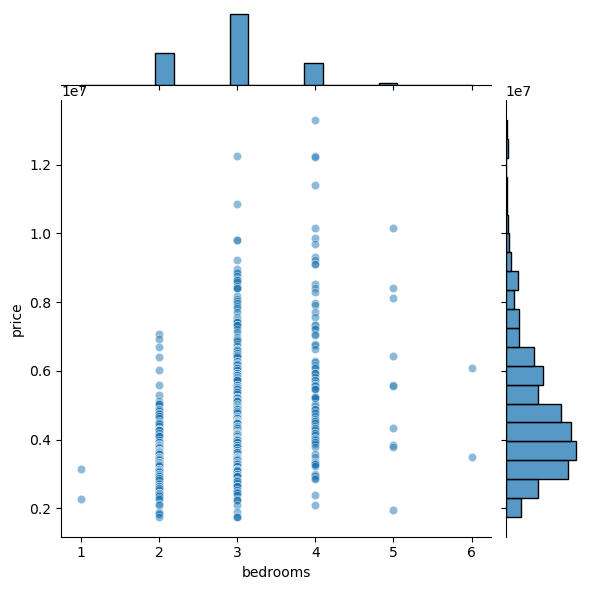

In [7]:
sns.jointplot(x='bedrooms', y='price' ,data=df , alpha = 0.5)

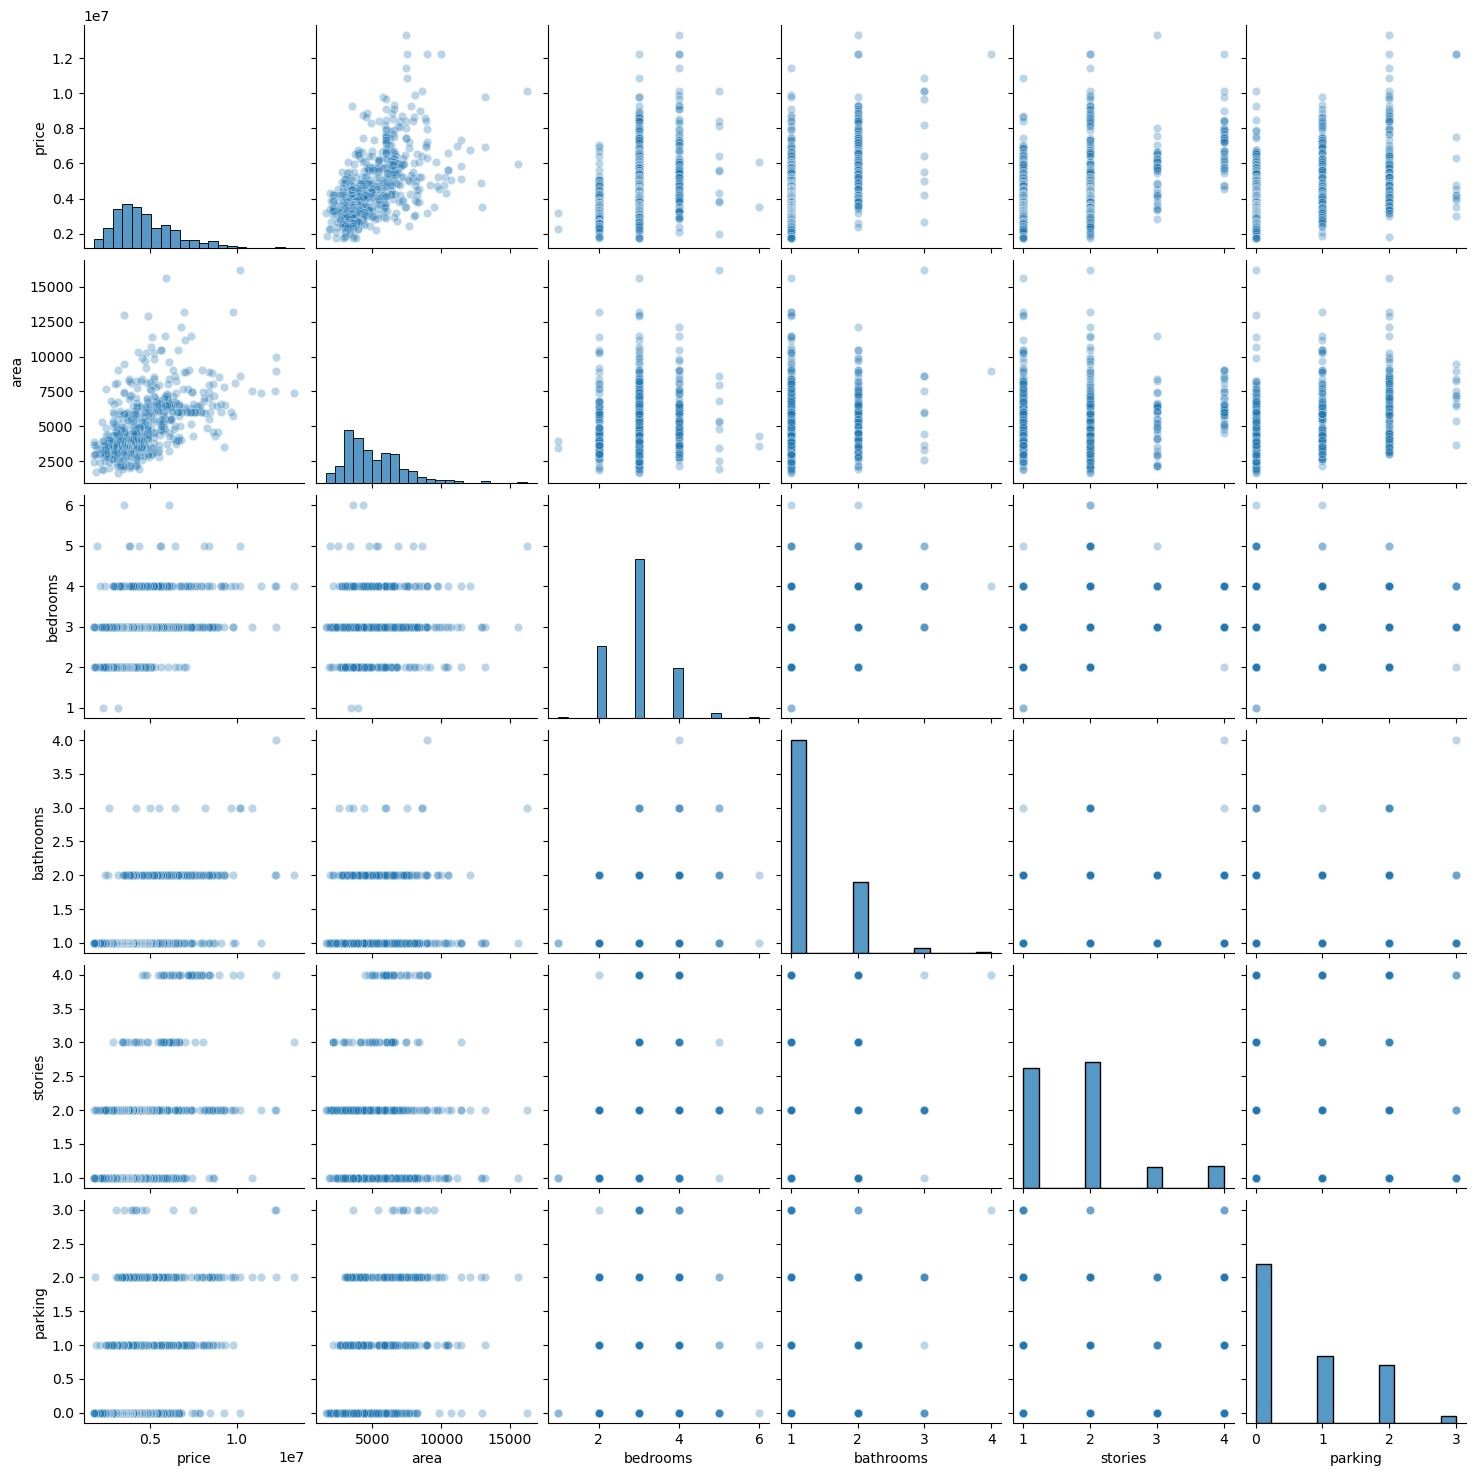

In [8]:
sns.pairplot(df,kind= 'scatter' , plot_kws={'alpha':0.3})

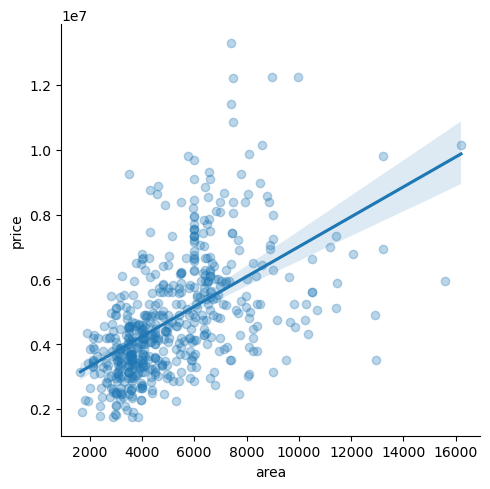

In [9]:
sns.lmplot(x='area'
           ,y='price'
           ,data=df
           ,scatter_kws={'alpha':0.3})

In [10]:
from sklearn.model_selection import train_test_split

In [29]:
X = df[['area','bedrooms','bathrooms'
        ,'parking'
        ,'stories']]
y = df['price']

In [30]:
X_train , X_test , y_train , y_test = train_test_split(X
                                                       ,y
                                                       ,random_state=42
                                                       ,test_size=20)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lm = LinearRegression()

In [33]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
X_test


,area,bedrooms,bathrooms,parking,stories
316,5900,4,2,1,2
77,6500,3,2,0,3
360,4040,2,1,0,1
90,5000,3,1,0,2
493,3960,3,1,0,1
209,6720,3,1,0,1
176,8520,3,1,2,1
249,4990,4,2,0,2
516,3240,2,1,1,1
426,2700,3,1,0,1


In [36]:
lm.coef_

array([3.25966089e+02, 1.63239808e+05, 1.20318483e+06, 3.69620888e+05,
       5.35341944e+05])

In [38]:
cdf = pd.DataFrame(lm.coef_, X.columns,columns=['coef'])
print(cdf)

                   coef
area       3.259661e+02
bedrooms   1.632398e+05
bathrooms  1.203185e+06
parking    3.696209e+05
stories    5.353419e+05


In [39]:
predicted_price = lm.predict(X_test)
predicted_price

array([6269906.00432282, 6467966.90547669, 3228981.80364974,
       4240491.00142687, 3366144.32495017, 4265810.73096905,
       5591791.46675817, 5603655.97553689, 3337829.82001094,
       2955427.05263721, 9786984.72499957, 3194429.39820119,
       3124672.65512582, 3621155.43206605, 3904745.92961548,
       6200287.11244877, 3099352.92558364, 4936077.97823516,
       4887183.06486456, 3867875.3383588 ])

Text(0.5, 1.0, 'here the model predicting the house prices')

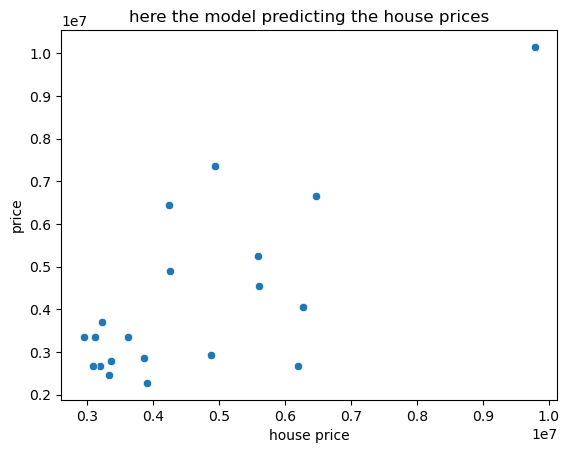

In [40]:
sns.scatterplot(x=predicted_price, y = y_test)
plt.xlabel('house price')
plt.title('here the model predicting the house prices')

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [42]:
print("MSE:", mean_squared_error(y_test,predicted_price))
print("MAE:", mean_absolute_error(y_test,predicted_price))
print("RMSE:", math.sqrt(mean_squared_error(y_test,predicted_price)))

MSE: 1971744056379.9624
MAE: 1066147.1970098685
RMSE: 1404188.0416738929


In [43]:
residuals = y_test-predicted_price
residuals

316   -2.209906e+06
77     1.820331e+05
360    4.810182e+05
90     2.199509e+06
493   -5.661443e+05
209    6.341893e+05
176   -3.417915e+05
249   -1.060656e+06
516   -8.878298e+05
426    3.975729e+05
6      3.630153e+05
497   -5.344294e+05
422    2.353273e+05
424   -2.611554e+05
529   -1.629746e+06
499   -3.540287e+06
498   -4.393529e+05
55     2.413922e+06
476   -1.947183e+06
486   -9.978753e+05
Name: price, dtype: float64

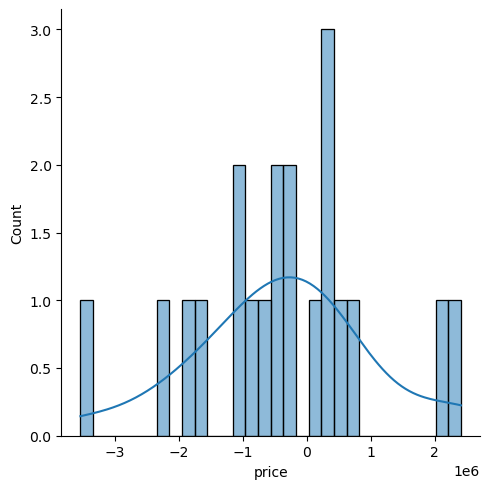

In [44]:
sns.displot(residuals, bins = 30  , kde= True)

In [45]:
import pylab
import scipy.stats as stats

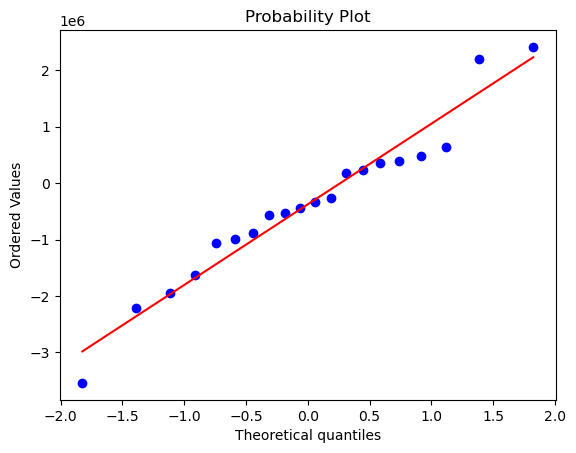

In [46]:
stats.probplot(residuals
               , dist='norm'
               ,plot=pylab)

pylab.show()

In [47]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

IMPROVING MODEL MY CONVERTING OBJECT DATA INTO INTEGER DATA

In [48]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [53]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]



In [55]:
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

C:\Users\Amey\AppData\Local\Temp\ipykernel_30024\865435927.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [56]:
df[binary_cols].head()


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [57]:
df = pd.get_dummies(
    df
    , columns=['furnishingstatus']
    , drop_first=True
    , dtype= int
)

In [58]:
print(df.head())
print(df.dtypes)

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                                0                             0  
1                       

In [59]:
df.head()
df.dtypes


price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [60]:
X2 = [['area','bedrooms','bathrooms','stories'
       ,'mainroad','guestroom','basemnt','hotwaterheating'
       ,'airconditioning','parking','prefarea'
       ,'furnishingstatus_semi-furnished'
       ,'furnishingstatus_unfurnished']]
y2 = ['price']

In [67]:
import numpy as np

X2 = np.array(X2)

print(X2.shape)
print(y.shape)

(1, 13)
(545,)


In [72]:
y = np.array(y)

In [73]:
print(X2.shape)
print(y.shape)

(1, 13)
(545,)


In [75]:
X2 = df.drop('price', axis=1)
y2 = df['price']

In [76]:
print(X2.shape)
print(y2.shape)

(545, 13)
(545,)


In [77]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=42
)

In [78]:
lm2 = LinearRegression()

In [79]:
lm2.fit(X2_train,y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
lm2.coef_

array([ 2.53287252e+02,  8.08931413e+04,  1.11475118e+06,  4.17267580e+05,
        4.08073682e+05,  2.75710533e+05,  4.82603522e+05,  6.16375423e+05,
        6.85839346e+05,  3.03111236e+05,  5.09192089e+05, -1.21652663e+05,
       -3.91191241e+05])

In [94]:
cdf = pd.DataFrame(lm.coef_,X.columns,columns=['coef'])
print(cdf)

                   coef
area       3.259661e+02
bedrooms   1.632398e+05
bathrooms  1.203185e+06
parking    3.696209e+05
stories    5.353419e+05


In [ ]:
predictrions = lm2.predict(X2_test)
predictrions

array([5372312.61614641, 7069241.00525806, 3099290.78784024,
       4526446.61703974, 3281573.61192656, 3589455.18752547,
       5728625.30074516, 6422877.52476236, 2797870.49568591,
       2554357.99210551, 9693560.19894657, 2802903.7613103 ,
       3026465.95300836, 3433891.33202092, 3792786.34565513,
       5321204.36478554, 2999852.37322993, 4813306.52790376,
       4572077.61633939, 3595733.80237382, 5605701.03333098,
       5838934.41614982, 2730716.89440108, 4837741.37096246,
       5638460.49223857, 7809681.30410656, 3347443.37529207,
       5328750.6625753 , 8323072.83237389, 3374792.28854334,
       6379706.15324898, 3397999.89564252, 6709115.8233402 ,
       4249666.18392567, 3594972.20315591, 5842994.13027721,
       5115480.11172668, 4359421.90319847, 3046570.15372423,
       4597379.56416964, 4784358.1758961 , 3411743.78220679,
       7048978.02507302, 4062741.36892573, 3785699.24160861,
       4286017.77250844, 6729020.20739641, 4133428.23821411,
       3845434.09183083,

Text(0.5, 1.0, 'evaluatine our ML model')

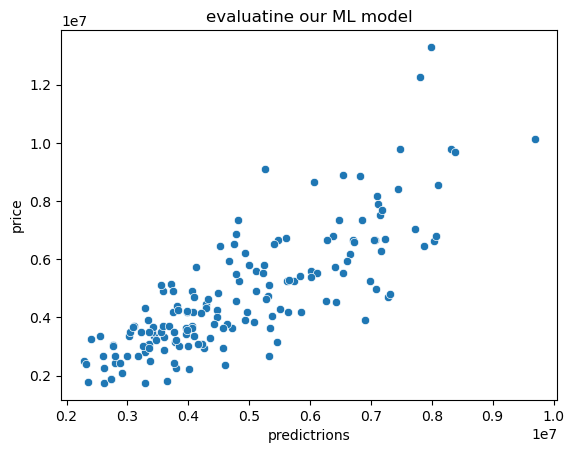

In [84]:
sns.scatterplot(x=predictrions,y=y2_test)
plt.xlabel('predictrions')
plt.title('evaluatine our ML model')

In [85]:
print("MSE:", mean_squared_error(y2_test,predictrions))
print("MSE:", mean_absolute_error(y2_test,predictrions))
print("RMSE:", math.sqrt(mean_squared_error(y2_test,predictrions)))

MSE: 1523019469501.2913
MSE: 920392.9397607957
RMSE: 1234106.7496376848


In [87]:
residuals2 = y2_test - predictrions
residuals2

316   -1.312313e+06
77    -4.192410e+05
360    6.107092e+05
90     1.913553e+06
493   -4.815736e+05
           ...     
395   -2.622572e+05
425   -7.332088e+05
195   -2.120389e+06
452   -2.309979e+06
154    3.103569e+05
Name: price, Length: 164, dtype: float64

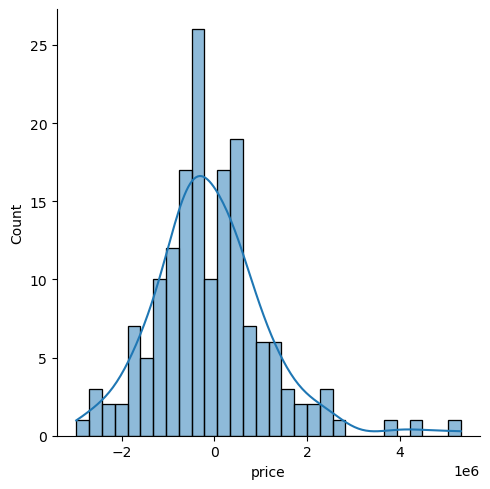

In [88]:
sns.displot(residuals2,bins=30, kde = True)

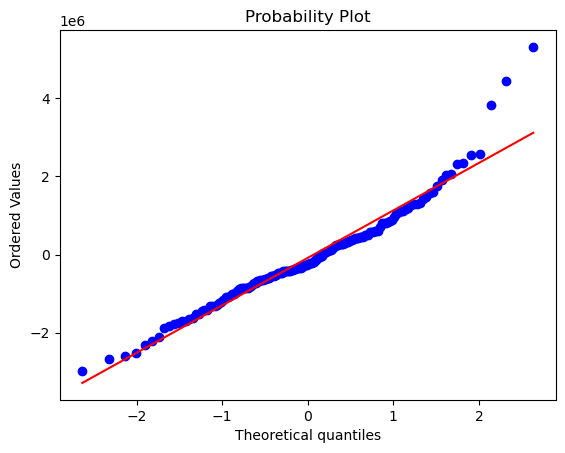

In [89]:
stats.probplot(residuals2
               , dist='norm'
               ,plot=pylab)

pylab.show()